In [3]:
# import joblib
# import time
# import os
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# from sklearn.ensemble import GradientBoostingClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from sklearn.metrics import (
#     accuracy_score, 
#     precision_score, 
#     recall_score, 
#     f1_score, 
#     confusion_matrix, 
#     classification_report
# )

# print("="*60)
# print("SISTEM EKSPERIMEN USULAN + AUTO-PLOT CONFUSION MATRIX")
# print("="*60)

# # 1. LOAD DATASET (.values)
# print("\n[1/4] Memuat file dataset steril (.values)...")
# try:
#     X_train_resampled = joblib.load('X_train_resampled_values_v1.pkl')
#     y_train_resampled = joblib.load('y_train_resampled_values_v1.pkl')
#     X_test = joblib.load('X_test_values_v1.pkl')
#     y_test = joblib.load('y_test_values_v1.pkl')
#     print("✓ Data berhasil dimuat!")
# except Exception as e:
#     print(f"❌ Gagal memuat data! Error: {e}")
#     exit()

# # 2. INISIALISASI MODEL USULAN (RTX 3050 6GB)
# print("\n[2/4] Mengonfigurasi arsitektur model...")
# models_usulan = {
#     'Gradient_Boosting_CPU': GradientBoostingClassifier(
#         n_estimators=100, 
#         random_state=42
#     ),
#     'XGBoost_GPU': XGBClassifier(
#         n_estimators=100,
#         random_state=42,
#         device='cuda',             # CUDA RTX 3050
#         tree_method='hist',        # Hemat VRAM
#         eval_metric='logloss',
#         n_jobs=-1
#     ),
#     'LightGBM_GPU': LGBMClassifier(
#         n_estimators=100,
#         random_state=42,
#         device='gpu',              # GPU LightGBM
#         gpu_platform_id=0,
#         gpu_device_id=0,
#         n_jobs=-1,
#         verbose=-1
#     )
# }

# # 3. FUNGSI UNTUK MEMBUAT PLOT CONFUSION MATRIX
# def plot_and_save_cm(cm, model_name, data_type):
#     """
#     Fungsi khusus Jupyter Notebook (.ipynb) agar gambar
#     langsung tercetak di bawah cell DAN tersimpan ke folder.
#     """
#     plt.figure(figsize=(6, 5))
    
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
#                 xticklabels=['Aman (0)', 'Fraud (1)'],
#                 yticklabels=['Aman (0)', 'Fraud (1)'])
    
#     plt.title(f'Confusion Matrix - {model_name} ({data_type})', fontsize=12, fontweight='bold', pad=15)
#     plt.ylabel('Actual Label', fontsize=10)
#     plt.xlabel('Predicted Label', fontsize=10)
#     plt.tight_layout()
    
#     # 1. Simpan dulu ke folder biar aman buat laporan Word
#     filename = f'cm_{model_name.lower()}_{data_type.lower()}.png'
#     plt.savefig(filename, dpi=300)
    
#     # 2. Paksa Jupyter buat ngetik/nge-print gambarnya di bawah cell
#     plt.show()

# # 4. PROSES TRAINING, EVALUASI, & PLOTTING
# print("\n[3/4] Memulai proses komputasi & visualisasi...")
# print("="*60)

# for name, model in models_usulan.items():
#     print(f"\n➔ Menjalankan Algoritma: {name}")
#     print("-" * 40)
    
#     # Proses Training
#     start_time = time.time()
#     model.fit(X_train_resampled, y_train_resampled)
#     train_time = time.time() - start_time
#     print(f"✓ Waktu Training: {train_time:.2f} detik")
    
#     # Prediksi hasil
#     preds_test = model.predict(X_test)
#     preds_train = model.predict(X_train_resampled)
    
#     # Hitung matriks evaluasi dasar
#     acc_test = accuracy_score(y_test, preds_test)
#     prec_test = precision_score(y_test, preds_test)
#     rec_test = recall_score(y_test, preds_test)
#     f1_test = f1_score(y_test, preds_test)
#     f1_train = f1_score(y_train_resampled, preds_train)
    
#     # Hitung Confusion Matrix mentah
#     cm_test = confusion_matrix(y_test, preds_test)
#     cm_train = confusion_matrix(y_train_resampled, preds_train)
    
#     # GENERATE PLOT SEABORN & SIMPAN KE FOLDER
#     print("\n[ GENERATING VISUAL PLOTS ]")
#     plot_and_save_cm(cm_test, name, 'Data_Test')
#     plot_and_save_cm(cm_train, name, 'Data_Train')
    
#     # Tampilkan angka ringkasan di konsol
#     print("\n[ RINGKASAN METRIK EVALUASI ]")
#     print(f"  - Accuracy (Test)       : {acc_test:.4f}")
#     print(f"  - Precision (Test)      : {prec_test:.4f}")
#     print(f"  - Recall (Test)         : {rec_test:.4f}")
#     print(f"  - F1-Score (DATA TEST)  : {f1_test:.4f}")
#     print(f"  - F1-Score (DATA TRAIN) : {f1_train:.4f}")
    
#     print("\n[ DETAIL KLASIFIKASI ]")
#     print(classification_report(y_test, preds_test, digits=4))
    
#     # Export model ke file .pkl
#     model_filename = f'{name}_final_usulan.pkl'
#     joblib.dump(model, model_filename)
#     print(f"✓ Model biner berhasil disimpan: {model_filename}")
#     print("-" * 40)

# print("\n" + "="*60)
# print("PROSES SELESAI! SILAKAN CEK FOLDER PROJECT KAMU UNTUK GAMBAR PNG PLOTNYA")
# print("="*60)

In [4]:
import joblib
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("="*60)
print("BOOSTING EXPERIMENT + THRESHOLD OPTIMIZATION")
print("="*60)

BOOSTING EXPERIMENT + THRESHOLD OPTIMIZATION


In [5]:
print("\n[LOAD DATA]")

X_train_resampled = joblib.load('X_train_resampled_values_v1.pkl')
y_train_resampled = joblib.load('y_train_resampled_values_v1.pkl')
X_test = joblib.load('X_test_values_v1.pkl')
y_test = joblib.load('y_test_values_v1.pkl')

print("Train:", X_train_resampled.shape)
print("Test :", X_test.shape)


[LOAD DATA]
Train: (8896112, 10)
Test : (1908786, 10)


In [6]:
models = {
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        device="cuda",
        tree_method="hist",
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,
        random_state=42,
        device="gpu",
        verbose=-1
    )
}

In [7]:
def plot_cm(cm, name, dtype):
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['0', '1'],
        yticklabels=['0', '1']
    )

    plt.title(f"{name} - {dtype}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/cm_{name}_{dtype}.png", dpi=300, bbox_inches="tight")

    plt.show()

In [8]:
trained_models = {}

print("\n[TRAINING MODELS]")

for name, model in models.items():
    print("\n==", name, "==")

    start = time.time()
    model.fit(X_train_resampled, y_train_resampled)
    print("Train time:", round(time.time() - start, 2), "sec")

    trained_models[name] = model

    joblib.dump(model, f"{name}_model.pkl")


[TRAINING MODELS]

== GradientBoosting ==
Train time: 1589.36 sec

== XGBoost ==
Train time: 5.12 sec

== LightGBM ==
Train time: 14.36 sec


In [9]:
def find_best_threshold(model, X, y):
    proba = model.predict_proba(X)[:, 1]

    best_t = 0.5
    best_f1 = 0

    for t in np.linspace(0.01, 0.99, 200):
        pred = (proba >= t).astype(int)
        f1 = f1_score(y, pred)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1

In [10]:
thresholds = {}

print("\n[THRESHOLD OPTIMIZATION]")

for name, model in trained_models.items():
    print("\n==", name, "==")

    best_t, best_f1 = find_best_threshold(model, X_test, y_test)

    thresholds[name] = best_t

    print("Best Threshold:", round(best_t, 3))
    print("Best F1 (threshold):", round(best_f1, 4))


[THRESHOLD OPTIMIZATION]

== GradientBoosting ==
Best Threshold: 0.985
Best F1 (threshold): 0.8003

== XGBoost ==
Best Threshold: 0.99
Best F1 (threshold): 0.7559

== LightGBM ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best Threshold: 0.99
Best F1 (threshold): 0.8491



[FINAL EVALUATION]

== GradientBoosting ==
Threshold: 0.985

METRICS:
Accuracy : 0.9995
Precision: 0.865
Recall   : 0.7446
F1 Test  : 0.8003
F1 Train : 0.8608

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998   1906351
           1     0.8650    0.7446    0.8003      2435

    accuracy                         0.9995   1908786
   macro avg     0.9323    0.8722    0.9000   1908786
weighted avg     0.9995    0.9995    0.9995   1908786



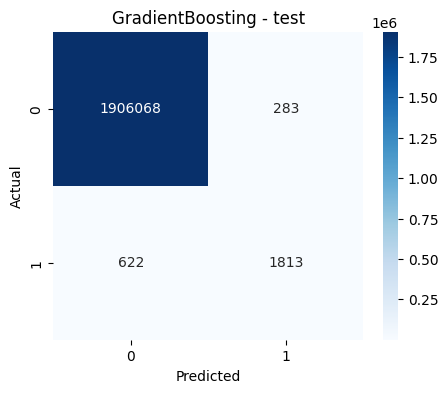

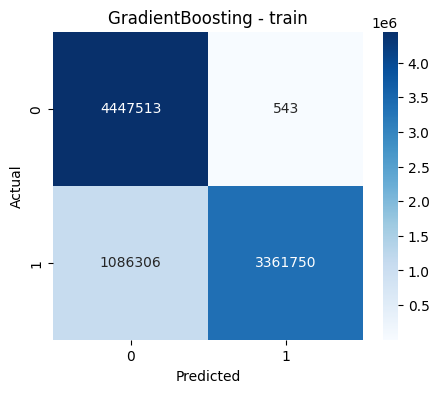


== XGBoost ==
Threshold: 0.99

METRICS:
Accuracy : 0.9993
Precision: 0.6937
Recall   : 0.8304
F1 Test  : 0.7559
F1 Train : 0.923

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9995    0.9997   1906351
           1     0.6937    0.8304    0.7559      2435

    accuracy                         0.9993   1908786
   macro avg     0.8467    0.9150    0.8778   1908786
weighted avg     0.9994    0.9993    0.9993   1908786



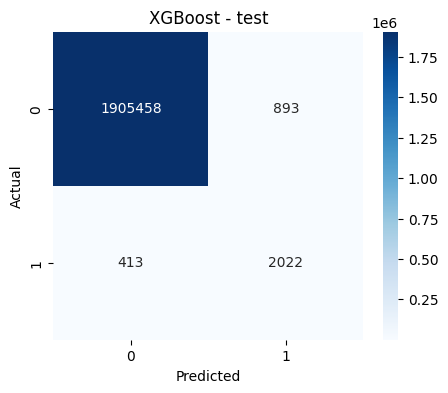

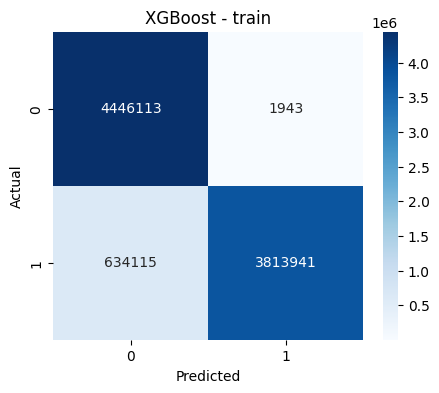


== LightGBM ==
Threshold: 0.99


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



METRICS:
Accuracy : 0.9996
Precision: 0.8736
Recall   : 0.8259
F1 Test  : 0.8491
F1 Train : 0.9099

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998   1906351
           1     0.8736    0.8259    0.8491      2435

    accuracy                         0.9996   1908786
   macro avg     0.9367    0.9129    0.9244   1908786
weighted avg     0.9996    0.9996    0.9996   1908786



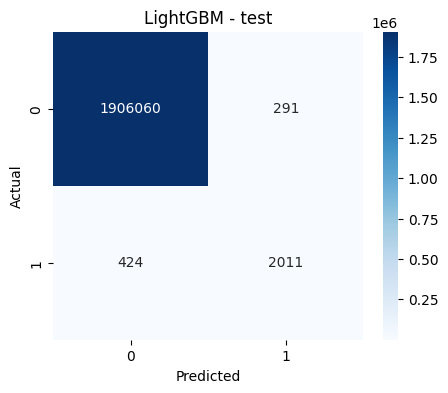

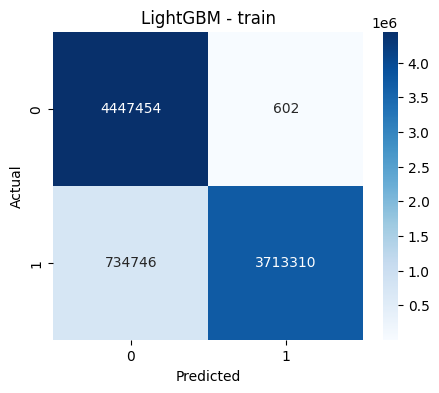

In [11]:
print("\n[FINAL EVALUATION]")

for name, model in trained_models.items():
    t = thresholds[name]

    print("\n==", name, "==")
    print("Threshold:", round(t, 3))

    proba_test = model.predict_proba(X_test)[:, 1]
    pred_test = (proba_test >= t).astype(int)

    proba_train = model.predict_proba(X_train_resampled)[:, 1]
    pred_train = (proba_train >= t).astype(int)

    acc = accuracy_score(y_test, pred_test)
    prec = precision_score(y_test, pred_test)
    rec = recall_score(y_test, pred_test)
    f1 = f1_score(y_test, pred_test)
    f1_train = f1_score(y_train_resampled, pred_train)

    print("\nMETRICS:")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 Test  :", round(f1,4))
    print("F1 Train :", round(f1_train,4))

    print("\nClassification Report:")
    print(classification_report(y_test, pred_test, digits=4))

    cm_test = confusion_matrix(y_test, pred_test)
    cm_train = confusion_matrix(y_train_resampled, pred_train)

    plot_cm(cm_test, name, "test")
    plot_cm(cm_train, name, "train")

    joblib.dump(model, f"{name}_final.pkl")